# Extended Cooling Tail

In [1]:
from snewpy.models.ccsn import Nakazato_2013
from snewpy.models.extended import ExtendedModel
from snewpy.flavor import ThreeFlavor

from astropy import units as u

import numpy as np
import matplotlib.pyplot as plt

## Model Initialization

Let's use a model from the `Nakazato_2013` family of simulations. There are many model parameters to choose from:

In [2]:
Nakazato_2013.param

{'progenitor_mass': <Quantity [13., 20., 30., 50.] solMass>,
 'revival_time': <Quantity [  0., 100., 200., 300.] ms>,
 'metallicity': [0.02, 0.004],
 'eos': ['LS220', 'shen', 'togashi']}

Since there are many valid and invalid combinations of parameters available, we will generate a list of valid parameters using the class function `get_param_combinations` and then select one of the particular models for plotting.

It is not really important which model we choose, so we'll pick a large metallicity model (high $Z$).

In [3]:
highZ_models = list(params for params in Nakazato_2013.get_param_combinations() if params['metallicity'] == 0.02)

This should be equivalent to the initialization:
```
model = Nakazato_2013(progenitor_mass=20<<u.solMass, revival_time=100<<u.ms, metallicity=0.02, eos='shen')
```

In [4]:
model_params = highZ_models[3]
model = Nakazato_2013(**model_params)
model

**Nakazato_2013 Model**: nakazato-shen-z0.02-t_rev100ms-s20.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $20$ $\mathrm{M_{\odot}}$|
|Revival time | $100$ $\mathrm{ms}$|
|Metallicity | 0.02 |
|EOS | shen |

Plot the model's neutrino fluxes for E = 20 MeV versus time.

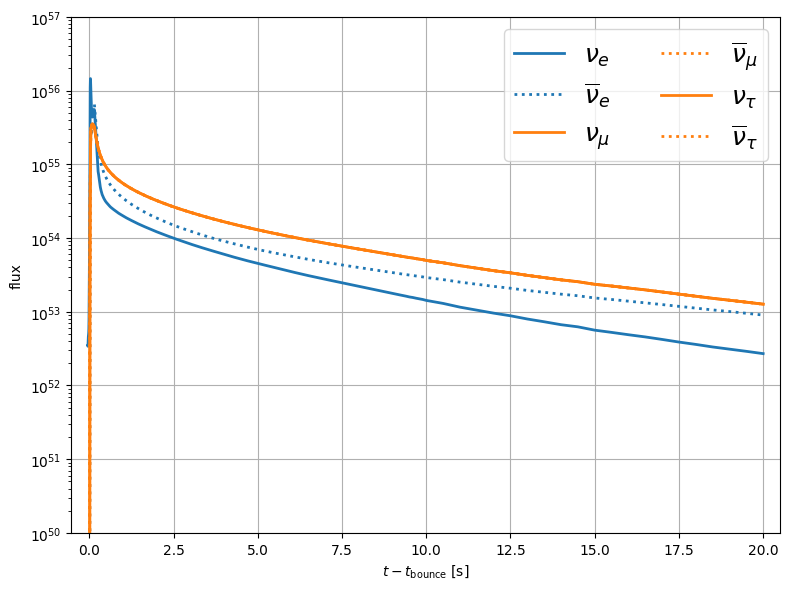

In [5]:
energy = 20 * u.MeV
times = model.get_time()
spectrum = model.get_initial_spectra(t=times, E=energy)

fig, ax = plt.subplots(1, figsize=(8,6), tight_layout=False)
for flavor in ThreeFlavor:
    ax.plot(times, spectrum[flavor].array.squeeze(),
            label=flavor.to_tex(),
            color = 'C0' if flavor.is_electron else 'C1',
            ls = '-' if flavor.is_neutrino else ':',
            lw = 2 )

ax.set(xlim=( (times[0]-0.5*u.s).value , (times[-1]+0.5*u.s).value ),
       xlabel=r'$t-t_{\rm bounce}$ [s]',
       ylabel=r'flux',
       yscale='log',
       ylim=(1e50,1e57))
ax.grid()
ax.legend(loc='upper right', ncol=2, fontsize=18);

Now make an ExtendedModel from the existing model. The extension follows the prescription found in Li, Roberts abd Beacom, doi:10.1103/physrevd.103.023016. The parameters k, A, tau_c and alpha are parameters for the generaliztion of equation (2) from that paper. A is the normalization: if set to None, the ExtendedModel will compute the appropriate normalaization so that the fluxes are continuous. We shall use the default values for the other paramaters but you might want to play around with them. 

In [6]:
ext_model = ExtendedModel(model, k=-1., A=None, tau_c=36.*u.s, alpha=2.66)

Set up the array of times for the ExtendedModel. In this case we'll extend the model to a time twice as long as the original

In [7]:
ext_times = np.linspace(times[0],2*times[-1],500)

Get the flux for the ExtendedModel again for a neutrino energy of 20 MeV, then plot it

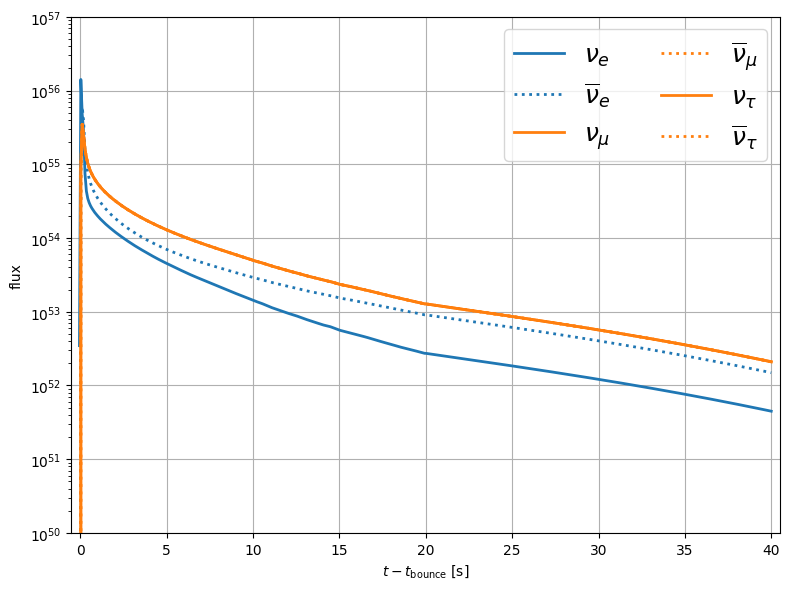

In [8]:
ext_spectrum = ext_model.get_initial_spectra(t=ext_times, E=energy)

fig, ax = plt.subplots(1, figsize=(8,6), tight_layout=False)
for flavor in ThreeFlavor:
    ax.plot(ext_times, ext_spectrum[flavor].array.squeeze(),
            label=flavor.to_tex(),
            color = 'C0' if flavor.is_electron else 'C1',
            ls = '-' if flavor.is_neutrino else ':',
            lw = 2 )

ax.set(xlim=( (ext_times[0]-0.5*u.s).value , (ext_times[-1]+0.5*u.s).value ),
       xlabel=r'$t-t_{\rm bounce}$ [s]',
       ylabel=r'flux',
       yscale='log',
       ylim=(1e50,1e57))
ax.grid()
ax.legend(loc='upper right', ncol=2, fontsize=18);